In [15]:
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

import matplotlib.pyplot as plt


dataset_df = pd.read_csv(
    r"C:\Users\apurb_oi8roye\Desktop\Earth_Observation\Earth_Observation\data\processed\labeled_dataset.csv"
)

# Encode string labels to integers
label_map = {
    "Built-up": 0,
    "Vegetation": 1,
    "Water": 2,
    "Cropland": 3,
    "Others": 4
}

dataset_df["label_id"] = dataset_df["label"].map(label_map)

train_df, test_df = train_test_split(
    dataset_df,
    test_size=0.4,
    random_state=42,
    shuffle=True
)

In [16]:
class LandUseDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.loc[idx, "image_name"]
        label = self.df.loc[idx, "label_id"]

        img_path = os.path.join(self.image_dir, img_name)
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

transform = transforms.Compose([
    transforms.Resize((224, 224)),   # required for ResNet
    transforms.ToTensor()
])



In [17]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Compute class weights using training data only
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df["label_id"]),
    y=train_df["label_id"]
)

# Convert to tensor and move to device
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

print("Class Weights:", class_weights)

# Use weighted CrossEntropyLoss
criterion = torch.nn.CrossEntropyLoss(weight=class_weights)

Class Weights: tensor([8.7836e-01, 2.0639e+00, 1.6030e+02, 2.9676e-01, 9.6180e+02])


In [18]:
image_dir = r"C:\Users\apurb_oi8roye\Desktop\Earth_Observation\Earth_Observation\data\raw\satellite\images\rgb"

train_dataset = LandUseDataset(train_df, image_dir, transform)
test_dataset  = LandUseDataset(test_df, image_dir, transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)



# Load pretrained ResNet18
model = models.resnet18(pretrained=True)

# Replace final layer for 5 classes
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 5)

model = model.to(device)


criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 10

for epoch in range(epochs):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs} | Loss: {running_loss:.4f}")

    

C:\Users\apurb_oi8roye\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\apurb_oi8roye\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/10 | Loss: 56.7930
Epoch 2/10 | Loss: 39.3473
Epoch 3/10 | Loss: 36.2839
Epoch 4/10 | Loss: 29.3798
Epoch 5/10 | Loss: 29.7789
Epoch 6/10 | Loss: 27.4626
Epoch 7/10 | Loss: 18.8398
Epoch 8/10 | Loss: 16.4240
Epoch 9/10 | Loss: 15.2954
Epoch 10/10 | Loss: 12.0357


In [19]:
model.eval()

y_true = []
y_pred = []
image_names=[]

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)

        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        y_pred.extend(preds)
        y_true.extend(labels.numpy())

        batch_indices = len(image_names)
        image_names.extend(
            test_df.iloc[batch_indices:batch_indices+len(labels)]["image_name"].values
        )

accuracy = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average="weighted")

print("Test Accuracy:", accuracy)
print("Test F1-score:", f1)

Test Accuracy: 0.9335620711166562
Test F1-score: 0.9317162361607714


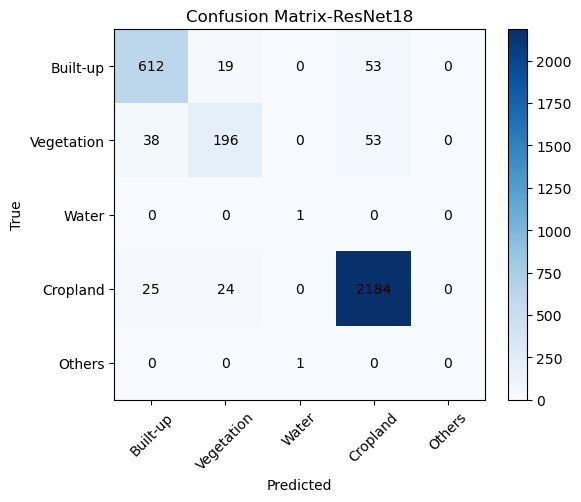

In [20]:
cm = confusion_matrix(y_true, y_pred)
class_names = list(label_map.keys())

plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")
plt.colorbar()

plt.xticks(range(len(class_names)), class_names, rotation=45)
plt.yticks(range(len(class_names)), class_names)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix-ResNet18")

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
confuse_fig=r"C:\Users\apurb_oi8roye\Desktop\Earth_Observation\Earth_Observation\Visualizations\confusion_matrix_RESNET18.png"
plt.savefig(confuse_fig, dpi=300)
plt.show()

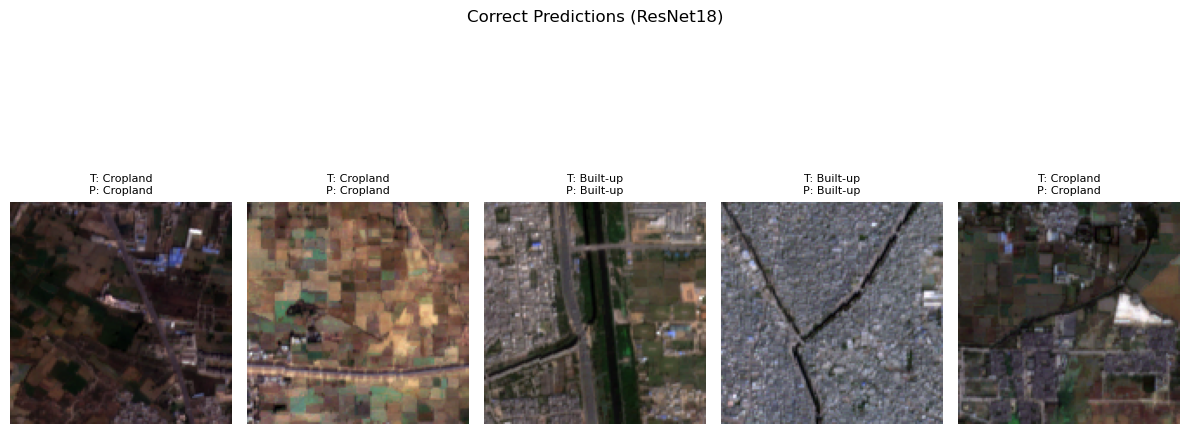

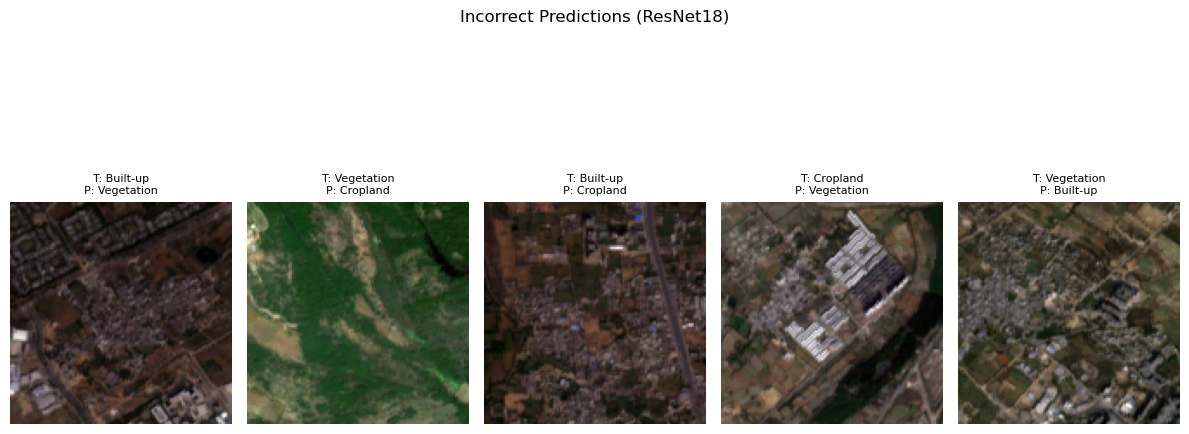

In [22]:
#Plot 5 correct and 5 incorrect predictions with images and labels (1 mark)

correct_indices = []
incorrect_indices = []

for i in range(len(y_true)):
    if y_true[i] == y_pred[i]:
        correct_indices.append(i)
    else:
        incorrect_indices.append(i)

import matplotlib.pyplot as plt
from PIL import Image
import os

class_names = list(label_map.keys())
image_dir = r"C:\Users\apurb_oi8roye\Desktop\Earth_Observation\Earth_Observation\data\raw\satellite\images\rgb"

def plot_samples(indices, title):
    plt.figure(figsize=(12, 6))
    
    for i, idx in enumerate(indices[:5]):
        img_path = os.path.join(image_dir, image_names[idx])
        img = Image.open(img_path)

        plt.subplot(1, 5, i+1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(
            f"T: {class_names[y_true[idx]]}\nP: {class_names[y_pred[idx]]}",
            fontsize=8
        )

    plt.suptitle(title)
    plt.tight_layout()
    output_correct=r"C:\Users\apurb_oi8roye\Desktop\Earth_Observation\Earth_Observation\Visualizations\correct_pred.png"
    plt.savefig(output_correct, dpi=300)
    output_incorrect=r"C:\Users\apurb_oi8roye\Desktop\Earth_Observation\Earth_Observation\Visualizations\incorrect_pred.png"
    plt.savefig(output_incorrect, dpi=300)
    plt.show()
plot_samples(correct_indices, "Correct Predictions (ResNet18)")
plot_samples(incorrect_indices, "Incorrect Predictions (ResNet18)")